# 🚗 Car Dheko – Used Car Price Prediction
## Integrated Preprocessing & EDA Pipeline

This notebook covers the full data processing workflow:
1. **Import & Concatenate** – Load all city datasets and merge them
2. **Structure Data** – Flatten nested JSON columns into a tabular format
3. **Drop Redundant Columns** – Remove irrelevant or duplicate fields
4. **Standardise Data Formats** – Clean units, extract numbers, fix types
5. **Handle Missing Values** – Impute using mean / median / mode
6. **Remove Outliers** – Z-score-based outlier removal
7. **Encode Categorical Variables** – Label encoding + persistence
8. **EDA** – Descriptive statistics, visualisations, and feature selection

---
## 1. Import & Concatenate All City Datasets

In [ ]:
import ast
import re
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# ── Configuration ─────────────────────────────────────────────────────────────
DATASET_DIR = '../DataSets'   # ← update path if needed

CITY_FILES = {
    'Bangalore' : 'bangalore_cars.xlsx',
    'Chennai'   : 'chennai_cars.xlsx',
    'Delhi'     : 'delhi_cars.xlsx',
    'Hyderabad' : 'hyderabad_cars.xlsx',
    'Jaipur'    : 'jaipur_cars.xlsx',
    'Kolkata'   : 'kolkata_cars.xlsx',
}
# ──────────────────────────────────────────────────────────────────────────────

frames = []
for city, filename in CITY_FILES.items():
    path = f'{DATASET_DIR}/{filename}'
    temp = pd.read_excel(path)
    temp['City'] = city
    frames.append(temp)
    print(f'  Loaded {city:12s}: {len(temp):,} rows')

raw_df = pd.concat(frames, ignore_index=True)
print(f'\nCombined dataset shape: {raw_df.shape}')
raw_df.head(3)

  Loaded Bangalore   : 1,481 rows
  Loaded Chennai     : 1,419 rows
  Loaded Delhi       : 1,485 rows
  Loaded Hyderabad   : 1,483 rows
  Loaded Jaipur      : 1,120 rows
  Loaded Kolkata     : 1,381 rows

Combined dataset shape: (8369, 6)


,new_car_detail,new_car_overview,new_car_feature,new_car_specs,car_links,City
0,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...,Bangalore
1,"{'it': 0, 'ft': 'Petrol', 'bt': 'SUV', 'km': '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/buy-used-car-details/...,Bangalore
2,"{'it': 0, 'ft': 'Petrol', 'bt': 'Hatchback', '...","{'heading': 'Car overview', 'top': [{'key': 'R...","{'heading': 'Features', 'top': [{'value': 'Pow...","{'heading': 'Specifications', 'top': [{'key': ...",https://www.cardekho.com/used-car-details/used...,Bangalore


---
## 2. Structure Data – Flatten Nested JSON Columns

Each row's nested columns (`new_car_detail`, `new_car_overview`, `new_car_specs`, `new_car_feature`) store
stringified Python dicts. We parse and flatten them into tidy tabular columns.

In [9]:
class CarDataPipeline:
    """
    End-to-end preprocessing pipeline for the CarDekho used-car dataset.

    Stages
    ------
    1. parse_nested_strings  – ast.literal_eval on nested-string columns
    2. flatten_detail        – json_normalize on new_car_detail
    3. flatten_overview      – extract key-value pairs from new_car_overview.top
    4. flatten_specs         – extract top + subHeading-prefixed data from new_car_specs
    5. build_flat_df         – concatenate all flat sub-frames
    6. drop_columns          – remove redundant / low-signal columns
    7. standardise_formats   – clean units, normalise numeric strings
    8. handle_missing        – impute with mean / median / mode
    9. remove_outliers       – Z-score filter (threshold = 3 σ)
    10. encode_categoricals  – LabelEncoder for nominal columns
    """

    # Columns that carry nested structures
    NESTED_COLS = ['new_car_detail', 'new_car_overview', 'new_car_specs', 'new_car_feature']

    # Columns dropped after flattening (redundant, duplicate, or near-empty)
    COLS_TO_DROP = [
        'Ignition type', 'oem', 'priceActual', 'priceSaving', 'priceFixedText',
        'trendingText.desc', 'trendingText.heading', 'trendingText.imgUrl',
        'Fuel Type', 'Kms Driven', 'RTO', 'Ownership', 'Transmission',
        'Year of Manufacture', 'Engine Displacement',
        'Dimensions_Ground Clearance Unladen', 'Miscellaneous_Alloy Wheel Size',
        'Miscellaneous_Cargo Volumn', 'Engine_Super Charger',
        'Dimensions_Length', 'Dimensions_Width', 'Dimensions_Height',
        'Dimensions_Wheel Base', 'Dimensions_Front Tread', 'Dimensions_Rear Tread',
        'Dimensions_Kerb Weight', 'Dimensions_Gross Weight',
        'Miscellaneous_Gear Box', 'Miscellaneous_Drive Type',
        'Miscellaneous_Seating Capacity', 'Miscellaneous_Steering Type',
        'Miscellaneous_Turning Radius', 'Miscellaneous_Front Brake Type',
        'Miscellaneous_Rear Brake Type', 'Miscellaneous_Top Speed',
        'Miscellaneous_Acceleration', 'Miscellaneous_Tyre Type',
        'Miscellaneous_No Door Numbers', 'Seats', 'Wheel Size',
        'Engine_Color', 'Engine_Engine Type', 'Engine_Displacement',
        'Engine_Max Power', 'Engine_Max Torque', 'Engine_No of Cylinder',
        'Engine_Values per Cylinder', 'Engine_Value Configuration',
        'Engine_Fuel Suppy System', 'Engine_BoreX Stroke',
        'Engine_Compression Ratio', 'Engine_Turbo Charger',
        'Ownership details', 'centralVariantId',
    ]

    # Columns that will be label-encoded
    CATEGORICAL_COLS = [
        'Fuel type', 'Body type', 'transmission', 'model',
        'variantName', 'Insurance Validity', 'City',
    ]

    # ── Stage 1: parse stringified dicts ──────────────────────────────────────
    def parse_nested_strings(self, df: pd.DataFrame) -> pd.DataFrame:
        """Convert stringified Python dicts back to actual dict objects."""
        df = df.copy()
        for col in self.NESTED_COLS:
            if col in df.columns:
                df[col] = df[col].apply(
                    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
                )
        return df

    # ── Stage 2: flatten new_car_detail ───────────────────────────────────────
    def flatten_detail(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        json_normalize on new_car_detail gives one column per top-level key
        (it, ft, bt, km, owner, oem, model, modelYear, price, …).
        """
        df_detail = pd.json_normalize(df['new_car_detail'])
        df_detail.rename(columns={
            'it'     : 'Ignition type',
            'ft'     : 'Fuel type',
            'bt'     : 'Body type',
            'km'     : 'Kilometers driven',
            'owner'  : 'Ownership details',
            'mileage': 'car_mileage',
            'engine' : 'car_engine',
        }, inplace=True)
        return df_detail

    # ── Stage 3: flatten new_car_overview ─────────────────────────────────────
    def flatten_overview(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Extracts key→value pairs stored in new_car_overview['top']
        (Registration Year, Insurance Validity, Fuel Type, …).
        """
        rows = []
        for record in df['new_car_overview']:
            row = {}
            if isinstance(record, dict) and 'top' in record:
                for item in record['top']:
                    if item.get('key'):
                        row[item['key']] = item.get('value')
            rows.append(row)
        return pd.DataFrame(rows, index=df.index)

    # ── Stage 4: flatten new_car_specs ────────────────────────────────────────
    def flatten_specs(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Extracts two layers from new_car_specs:
          • top  → Mileage, Engine, Max Power, Torque (as separate columns)
          • data → subHeading-prefixed keys, e.g. Engine_Displacement,
                   Dimensions_Length, Miscellaneous_Seating Capacity, …
        """
        top_rows, sub_rows = [], []

        for record in df['new_car_specs']:
            top_row, sub_row = {}, {}
            if isinstance(record, dict):
                # --- top-level specs ---
                for item in record.get('top', []):
                    if item.get('key'):
                        top_row[item['key']] = item.get('value')
                # --- detailed sub-heading specs ---
                for section in record.get('data', []):
                    heading = section.get('subHeading', 'Other')
                    for item in section.get('list', []):
                        if item.get('key'):
                            sub_row[f"{heading}_{item['key']}"] = item.get('value')
            top_rows.append(top_row)
            sub_rows.append(sub_row)

        df_top = pd.DataFrame(top_rows, index=df.index)
        df_sub = pd.DataFrame(sub_rows, index=df.index)
        return pd.concat([df_top, df_sub], axis=1)

    # ── Stage 5: assemble flat dataframe ──────────────────────────────────────
    def build_flat_df(self, df: pd.DataFrame) -> pd.DataFrame:
        """Concatenate all flattened sub-frames and attach the City column."""
        df_detail   = self.flatten_detail(df)
        df_overview = self.flatten_overview(df)
        df_specs    = self.flatten_specs(df)

        flat = pd.concat([df_detail, df_overview, df_specs], axis=1)
        flat['City'] = df['City'].values
        return flat

    # ── Stage 6: drop redundant columns ──────────────────────────────────────
    def drop_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """Remove columns that are duplicate, near-empty, or irrelevant."""
        existing = [c for c in self.COLS_TO_DROP if c in df.columns]
        return df.drop(columns=existing)

    # ── Stage 7: standardise data formats ────────────────────────────────────
    def standardise_formats(self, df: pd.DataFrame) -> pd.DataFrame:
        """Clean units and normalise mixed-format strings to proper numeric types."""
        df = df.copy()

        # Drop rows that are entirely null
        df.dropna(how='all', axis=0, inplace=True)

        # Ensure consistent dtypes for string processing
        df = df.convert_dtypes()

        # -- Kilometers driven: "70,000 km" → int 70000 ----------------------
        def clean_km(x):
            try:
                return int(str(x).replace(' km', '').replace(',', '').strip())
            except (ValueError, TypeError):
                return pd.NA

        df['Kilometers driven'] = df['Kilometers driven'].apply(clean_km)
        df['Kilometers driven'] = pd.to_numeric(df['Kilometers driven'], errors='coerce')

        # -- Price: "₹ 4.50 Lakh" → float 450000.0 ---------------------------
        def clean_price(x):
            if not isinstance(x, str):
                return pd.NA
            x = x.replace('₹', '').strip().lower()  # normalize to lowercase
            
            # Extract the numeric part
            nums = re.findall(r'\d*\.?\d+', x)
            if not nums:
                return pd.NA
            
            num = float(nums[0])
            
            # Check for unit indicators (case-insensitive partial match)
            if 'lakh' in x or 'lac' in x:
                return num * 1e5  # 1 Lakh = 100,000
            elif 'cr' in x or 'ore' in x:  # catches "Crore", "Cr", "ore" (typo)
                return num * 1e7  # 1 Crore = 10,000,000
            else:
                return num  # assume it's already in rupees

        df['price'] = df['price'].apply(clean_price).astype('float64')

        # -- Registration Year: "2018 (2018-2019)" → int 2018 ----------------
        def extract_year(x):
            if isinstance(x, str):
                m = re.search(r'\d{4}', x)
                return int(m.group(0)) if m else pd.NA
            return pd.NA

        df['Registration Year'] = df['Registration Year'].apply(extract_year)
        df['Registration Year'] = pd.to_numeric(df['Registration Year'], errors='coerce').astype('Int64')

        # -- Rename specs columns for clarity --------------------------------
        df.rename(columns={
            'Mileage'   : 'Mileage(kmpl)',
            'Engine'    : 'Engine(CC)',
            'Max Power' : 'Max Power(bhp)',
            'Torque'    : 'Torque(Nm)',
        }, inplace=True)

        # -- Mileage: handle both "kmpl" and "km/kg" units -------------------
        def clean_mileage(x):
            if not isinstance(x, str):
                return pd.NA
            try:
                if 'km/kg' in x:
                    return float(x.replace(' km/kg', '').strip()) * 0.425143707
                return float(x.replace(' kmpl', '').strip())
            except ValueError:
                return pd.NA

        # -- Generic helper: extract first numeric token ---------------------
        def first_number(x):
            if isinstance(x, str):
                nums = re.findall(r'\d*\.?\d+', x)
                return float(nums[0]) if nums else pd.NA
            return pd.NA

        numeric_spec_cols = {
            'Mileage(kmpl)': clean_mileage,
            'Engine(CC)'   : first_number,
            'Max Power(bhp)': first_number,
            'Torque(Nm)'   : first_number,
        }
        for col, fn in numeric_spec_cols.items():
            if col in df.columns:
                df[col] = df[col].apply(fn)
                df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')

        return df

    # ── Stage 8: handle missing values ───────────────────────────────────────
    def handle_missing(self, df: pd.DataFrame) -> pd.DataFrame:
        """Impute missing values using mean (numerical) and mode (categorical)."""
        df = df.copy()

        # Numerical → mean / median
        num_impute = {
            'price'          : df['price'].mean(),
            'Registration Year': df['Registration Year'].median(),
            'Mileage(kmpl)'  : df['Mileage(kmpl)'].mean(),
            'Engine(CC)'     : df['Engine(CC)'].mean(),
            'Max Power(bhp)' : df['Max Power(bhp)'].mean(),
            'Torque(Nm)'     : df['Torque(Nm)'].mean(),
        }
        for col, val in num_impute.items():
            if col in df.columns:
                df[col].fillna(val, inplace=True)

        # Categorical → mode
        cat_impute = ['Insurance Validity', 'Fuel type', 'Body type', 'transmission']
        for col in cat_impute:
            if col in df.columns and df[col].isnull().any():
                df[col].fillna(df[col].mode()[0], inplace=True)

        return df

    # ── Stage 9: remove outliers ─────────────────────────────────────────────
    def remove_outliers(self, df: pd.DataFrame, threshold: float = 3.0) -> pd.DataFrame:
        """
        Remove rows where any numerical column has a Z-score above *threshold*.
        Only numerical columns participate; categorical columns are untouched.
        """
        num_df = df.select_dtypes(include=[np.number])
        z = np.abs((num_df - num_df.mean()) / num_df.std())
        mask = (z < threshold).all(axis=1)
        print(f'  Outlier removal – before: {len(df):,}  after: {mask.sum():,}  '
              f'(removed {(~mask).sum():,} rows)')
        return df[mask].copy()

    # ── Stage 10: encode categorical variables ───────────────────────────────
    def encode_categoricals(
        self,
        df: pd.DataFrame,
        encoder_path: str = '../Utility Files/label_encoder.pkl'
    ) -> pd.DataFrame:
        """
        Apply LabelEncoder to each nominal categorical column.
        Saves the final encoder object to *encoder_path* for inference reuse.
        """
        df = df.copy()
        le = LabelEncoder()

        existing_cats = [c for c in self.CATEGORICAL_COLS if c in df.columns]
        for col in existing_cats:
            df[col] = df[col].astype(str)          # ensure uniform string type
            df[col] = le.fit_transform(df[col])

        with open(encoder_path, 'wb') as f:
            pickle.dump(le, f)
        print(f'  Label encoder saved → {encoder_path}')
        return df

    # ── Full pipeline ─────────────────────────────────────────────────────────
    def run(
        self,
        raw: pd.DataFrame,
        output_raw : str = '../Utility Files/car_data.xlsx',
        output_enc : str = '../Utility Files/encoded_car_data.xlsx',
        encoder_path: str = '../Utility Files/label_encoder.pkl',
    ) -> pd.DataFrame:
        """
        Execute all preprocessing stages sequentially.

        Parameters
        ----------
        raw          : Combined (all-city) raw DataFrame.
        output_raw   : Excel path for the cleaned (pre-encoding) data.
        output_enc   : Excel path for the final encoded data.
        encoder_path : Pickle path for the persisted LabelEncoder.

        Returns
        -------
        Fully preprocessed and encoded DataFrame.
        """
        print('▶ Stage 1 – Parsing nested strings …')
        df = self.parse_nested_strings(raw)

        print('▶ Stage 2-5 – Flattening & assembling …')
        df = self.build_flat_df(df)

        print(f'  Flat shape: {df.shape}')

        print('▶ Stage 6 – Dropping redundant columns …')
        df = self.drop_columns(df)
        print(f'  Shape after drop: {df.shape}')

        print('▶ Stage 7 – Standardising formats …')
        df = self.standardise_formats(df)

        print('▶ Stage 8 – Handling missing values …')
        before = df.isnull().sum().sum()
        df = self.handle_missing(df)
        after = df.isnull().sum().sum()
        print(f'  Nulls before: {before:,}   after: {after:,}')

        print('▶ Stage 9 – Removing outliers …')
        df = self.remove_outliers(df)

        # Save cleaned (pre-encoding) snapshot
        df.to_excel(output_raw, index=False)
        print(f'  Saved cleaned data → {output_raw}')

        print('▶ Stage 10 – Encoding categoricals …')
        df_enc = self.encode_categoricals(df, encoder_path=encoder_path)

        # Save encoded snapshot
        df_enc.to_excel(output_enc, index=False)
        print(f'  Saved encoded data → {output_enc}')

        print('\n✅ Pipeline complete.')
        return df_enc


print('CarDataPipeline class defined ✔')

CarDataPipeline class defined ✔


In [10]:
pipeline = CarDataPipeline()
df = pipeline.run(raw_df)

▶ Stage 1 – Parsing nested strings …
▶ Stage 2-5 – Flattening & assembling …
  Flat shape: (8369, 71)
▶ Stage 6 – Dropping redundant columns …
  Shape after drop: (8369, 16)
▶ Stage 7 – Standardising formats …
▶ Stage 8 – Handling missing values …
  Nulls before: 467   after: 0
▶ Stage 9 – Removing outliers …
  Outlier removal – before: 8,369  after: 7,853  (removed 516 rows)
  Saved cleaned data → ../Utility Files/car_data.xlsx
▶ Stage 10 – Encoding categoricals …
  Label encoder saved → ../Utility Files/label_encoder.pkl
  Saved encoded data → ../Utility Files/encoded_car_data.xlsx

✅ Pipeline complete.


In [11]:
print('Final shape:', df.shape)
df.head(3)

Final shape: (7853, 16)


,Fuel type,Body type,Kilometers driven,transmission,ownerNo,model,modelYear,variantName,price,Registration Year,Insurance Validity,Mileage(kmpl),Engine(CC),Max Power(bhp),Torque(Nm),City
0,4,3,120000,1,3,135,2015,1616,400000.0,2015,5,23.10,998.0,67.04,90.0,0
1,4,7,32706,1,2,41,2018,279,811000.0,2018,2,17.00,1497.0,121.31,150.0,0
2,4,3,11949,1,1,225,2018,127,585000.0,2018,2,23.84,1199.0,84.00,114.0,0


In [12]:
print('Data types:\n')
print(df.dtypes)
print('\nRemaining nulls:\n')
print(df.isnull().sum())

Data types:

Fuel type               int64
Body type               int64
Kilometers driven       int64
transmission            int64
ownerNo                 Int64
model                   int64
modelYear               Int64
variantName             int64
price                 float64
Registration Year       Int64
Insurance Validity      int64
Mileage(kmpl)         float64
Engine(CC)            float64
Max Power(bhp)        float64
Torque(Nm)            float64
City                    int64
dtype: object

Remaining nulls:

Fuel type             0
Body type             0
Kilometers driven     0
transmission          0
ownerNo               0
model                 0
modelYear             0
variantName           0
price                 0
Registration Year     0
Insurance Validity    0
Mileage(kmpl)         0
Engine(CC)            0
Max Power(bhp)        0
Torque(Nm)            0
City                  0
dtype: int64


---
## 3. Exploratory Data Analysis (EDA)
### 3.1 Descriptive Statistics

In [13]:
df.describe()

,Fuel type,Body type,Kilometers driven,transmission,ownerNo,model,modelYear,variantName,price,Registration Year,Insurance Validity,Mileage(kmpl),Engine(CC),Max Power(bhp),Torque(Nm),City
count,7853.000000,7853.000000,7853.000000,7853.000000,7853.0,7853.000000,7853.0,7853.000000,7.853000e+03,7853.0,7853.000000,7853.000000,7853.000000,7853.000000,7853.000000,7853.000000
mean,3.041258,5.349293,57245.255062,0.743920,1.320769,120.201197,2016.661658,1046.777919,8.005575e+05,2016.729148,3.788488,19.348359,1373.762638,99.997110,167.486217,2.429135
std,1.407653,2.242861,33613.844189,0.436495,0.55893,64.968653,3.609329,594.972918,7.111018e+05,3.599416,1.453283,3.336193,388.680952,34.853963,91.810705,1.707234
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2006.0,0.000000,2.000000e+01,2006.0,0.000000,8.000000,0.000000,34.200000,4.800000,0.000000
25%,1.000000,3.000000,30022.000000,0.000000,1.0,65.000000,2014.0,508.000000,4.000000e+05,2014.0,2.000000,17.190000,1197.000000,78.900000,110.000000,1.000000
50%,4.000000,7.000000,53000.000000,1.000000,1.0,124.000000,2017.0,1113.000000,6.000000e+05,2017.0,5.000000,19.160000,1199.000000,88.500000,138.000000,2.000000
75%,4.000000,8.000000,79000.000000,1.000000,2.0,157.000000,2019.0,1610.000000,9.000000e+05,2019.0,5.000000,21.400000,1498.000000,117.600000,200.000000,4.000000
max,4.000000,9.000000,260000.000000,1.000000,3.0,262.000000,2023.0,1949.000000,5.200000e+06,2023.0,6.000000,30.460000,2835.000000,241.300000,500.000000,5.000000


In [14]:
print('─── Median ───')
display(df.median(numeric_only=True).rename('median').to_frame())

─── Median ───


,median
Fuel type,4.0
Body type,7.0
Kilometers driven,53000.0
transmission,1.0
ownerNo,1.0
model,124.0
modelYear,2017.0
variantName,1113.0
price,600000.0
Registration Year,2017.0


In [15]:
print('─── Mode (first) ───')
display(df.mode().iloc[0].rename('mode').to_frame())

─── Mode (first) ───


,mode
Fuel type,4.0
Body type,3.0
Kilometers driven,120000.0
transmission,1.0
ownerNo,1.0
model,51.0
modelYear,2018.0
variantName,1616.0
price,650000.0
Registration Year,2018.0


### 3.2 Data Visualisation

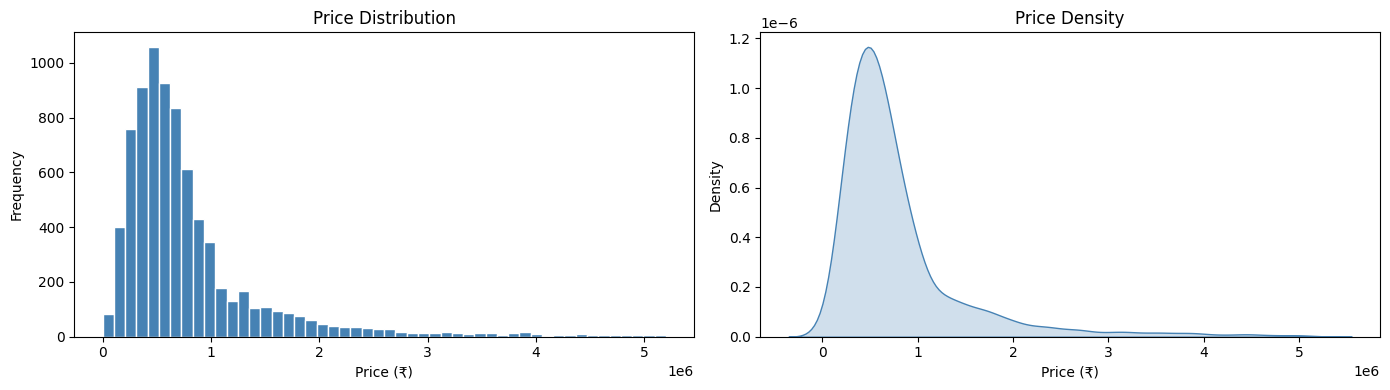

In [16]:
# ── Price distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Frequency')

# KDE
sns.kdeplot(df['price'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('Price Density')
axes[1].set_xlabel('Price (₹)')

plt.tight_layout()
plt.show()

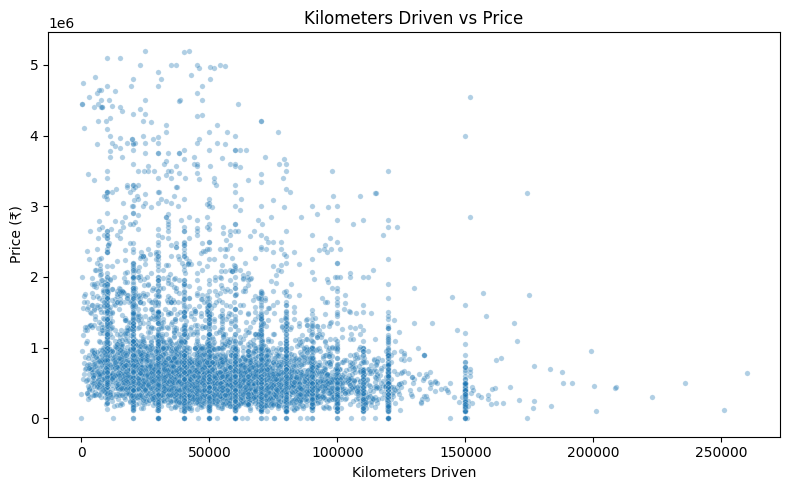

In [17]:
# ── Kilometers Driven vs Price ────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Kilometers driven', y='price', data=df, alpha=0.35, s=15)
plt.title('Kilometers Driven vs Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

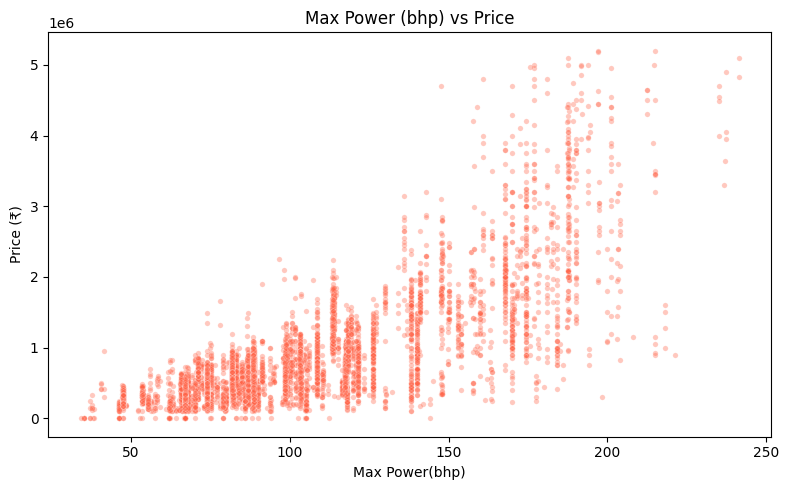

In [18]:
# ── Max Power vs Price ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Max Power(bhp)', y='price', alpha=0.35, s=15, color='tomato')
plt.title('Max Power (bhp) vs Price')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

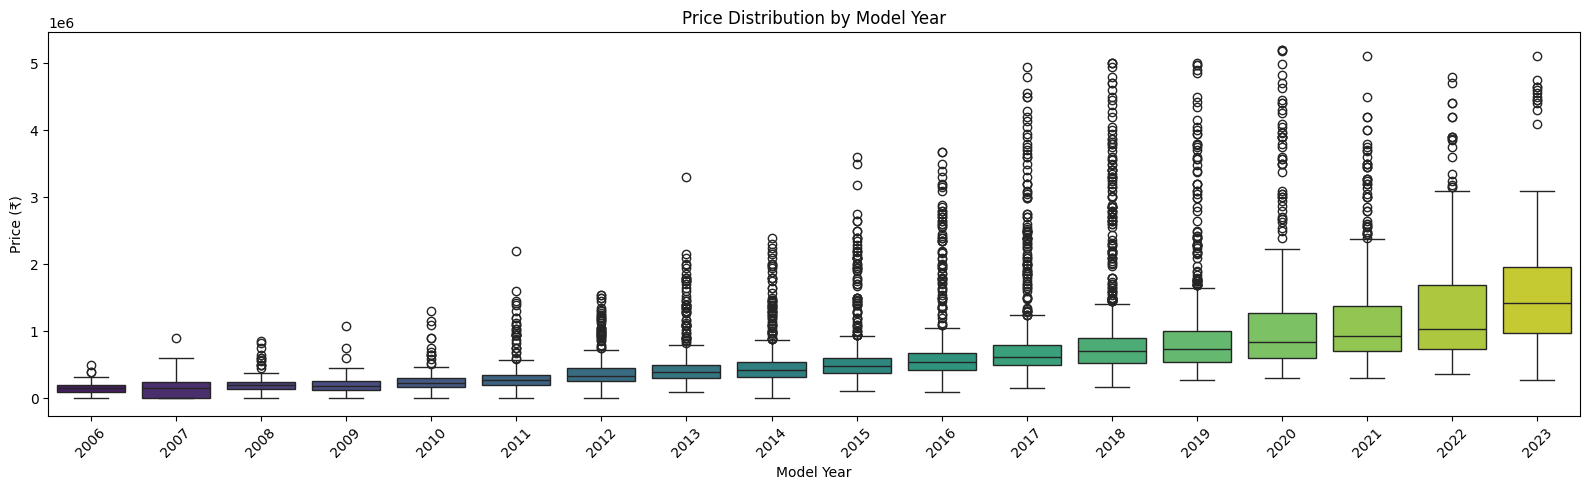

In [19]:
# ── Price by Model Year (box plot) ────────────────────────────────────────────
plt.figure(figsize=(16, 5))
order = sorted(df['modelYear'].dropna().unique())
sns.boxplot(x='modelYear', y='price', data=df, order=order, palette='viridis')
plt.xticks(rotation=45)
plt.title('Price Distribution by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()

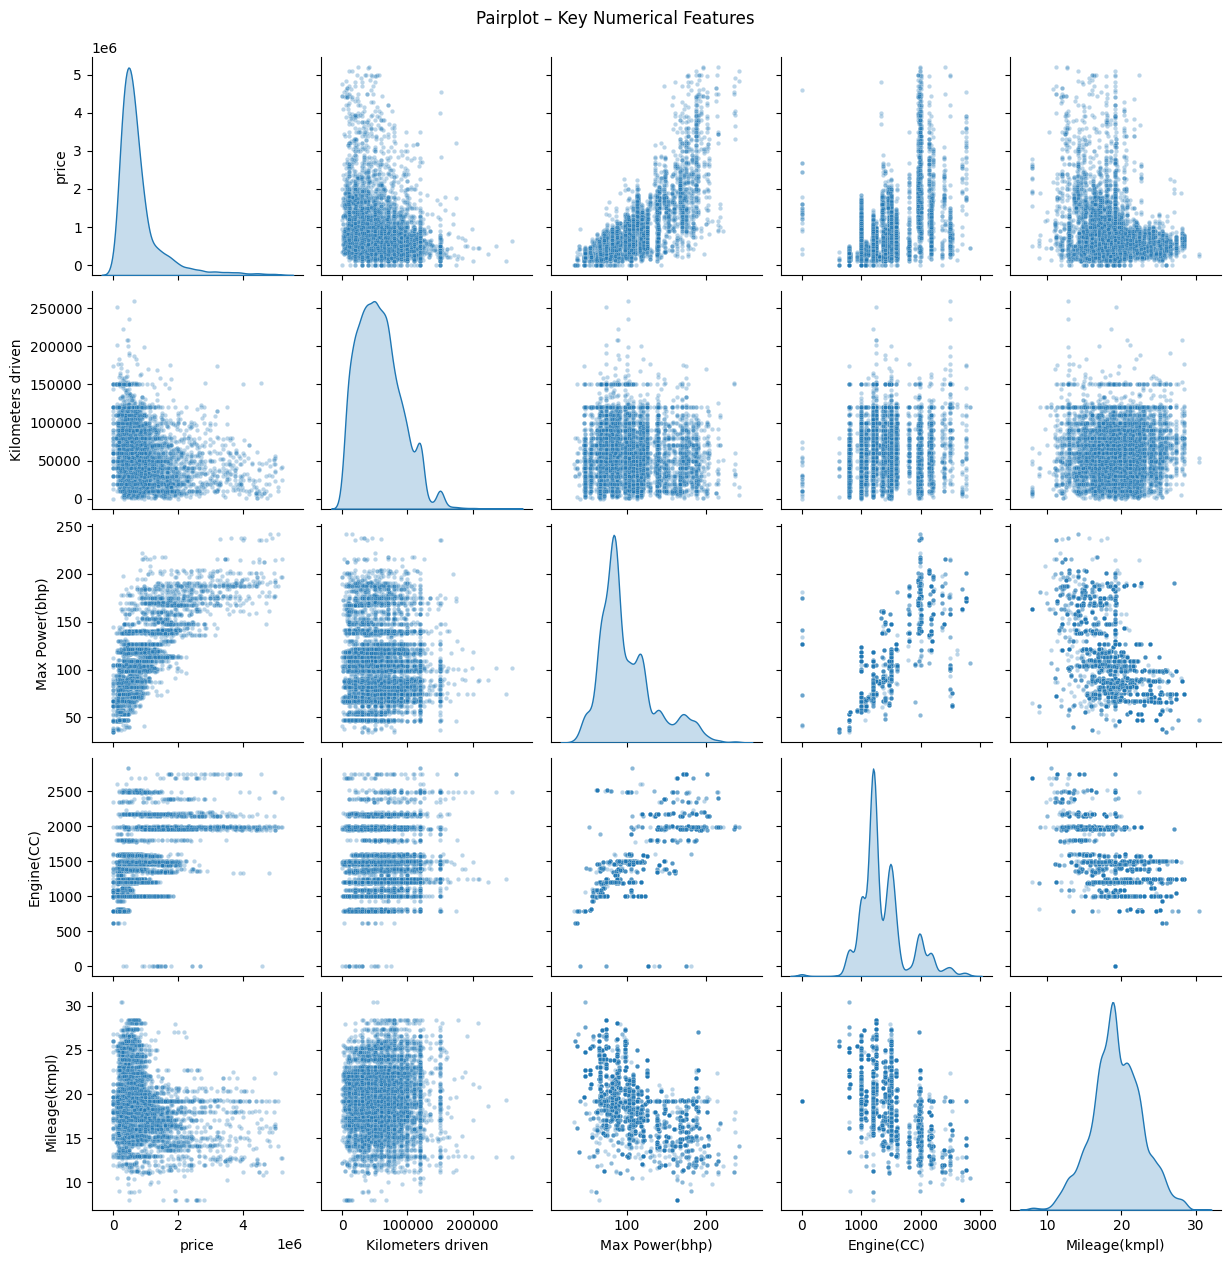

In [20]:
# ── Pairplot of key numerical features ───────────────────────────────────────
pair_cols = ['price', 'Kilometers driven', 'Max Power(bhp)', 'Engine(CC)', 'Mileage(kmpl)']
existing_pair_cols = [c for c in pair_cols if c in df.columns]

sns.pairplot(df[existing_pair_cols].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot – Key Numerical Features', y=1.01)
plt.show()

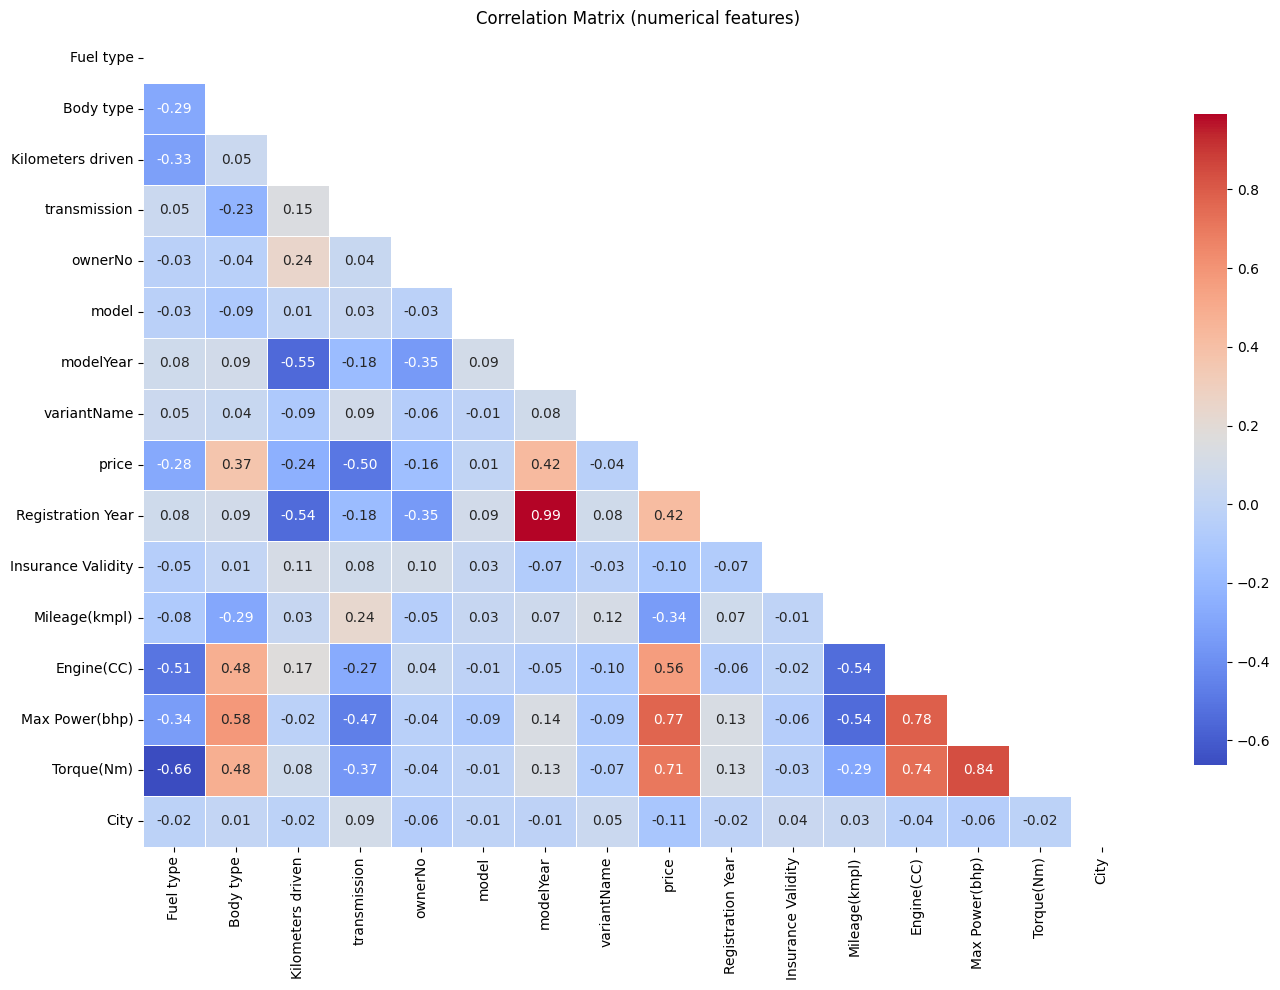

In [21]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper-triangle mask
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.4,
    cbar_kws={'shrink': 0.8},
)
plt.title('Correlation Matrix (numerical features)')
plt.tight_layout()
plt.show()

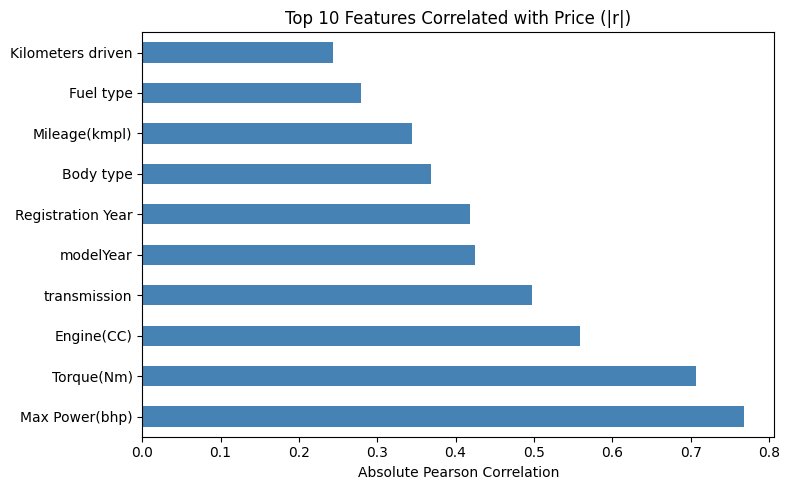

Max Power(bhp)       0.768349
Torque(Nm)           0.706602
Engine(CC)           0.559059
transmission         0.497647
modelYear            0.424762
Registration Year    0.418919
Body type            0.368686
Mileage(kmpl)        0.344260
Fuel type            0.279212
Kilometers driven    0.243437
Name: price, dtype: float64


In [22]:
# ── Top 10 correlations with Price ───────────────────────────────────────────
price_corr = (
    corr['price']
    .drop('price')
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
price_corr.plot(kind='barh', color='steelblue')
plt.title('Top 10 Features Correlated with Price (|r|)')
plt.xlabel('Absolute Pearson Correlation')
plt.tight_layout()
plt.show()
print(price_corr)

### 3.3 Feature Selection via Random Forest Importance

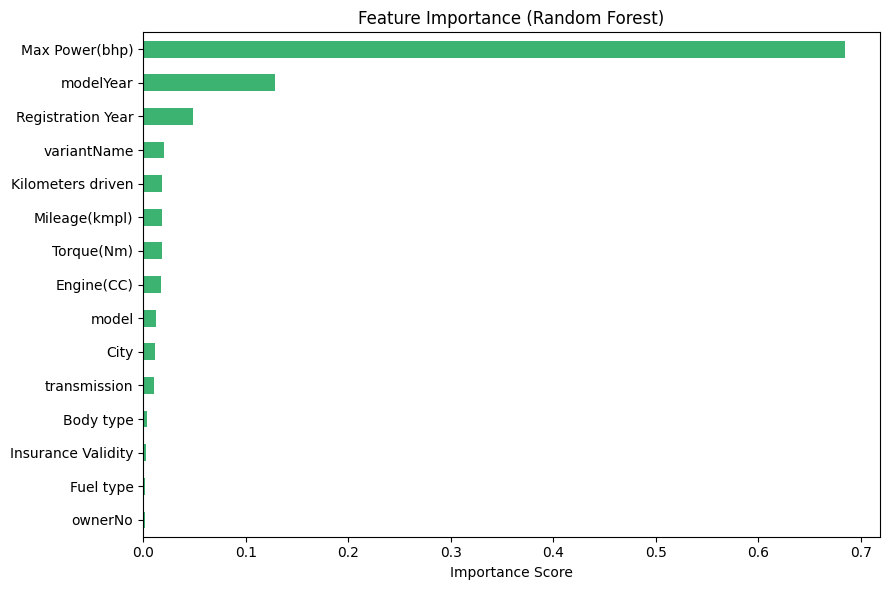


Top 10 features by importance:
Max Power(bhp)       0.684687
modelYear            0.128165
Registration Year    0.048839
variantName          0.020089
Kilometers driven    0.018565
Mileage(kmpl)        0.018510
Torque(Nm)           0.018091
Engine(CC)           0.017051
model                0.012801
City                 0.011934
dtype: float64


In [23]:
# Use only rows without any nulls for a quick importance ranking
df_fs = df.select_dtypes(include=[np.number]).dropna()

X_fs = df_fs.drop(columns=['price'])
y_fs = df_fs['price']

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_fs, y_fs)

importance_series = (
    pd.Series(rf.feature_importances_, index=X_fs.columns)
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))
importance_series.plot(kind='barh', color='mediumseagreen')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 features by importance:')
print(importance_series.sort_values(ascending=False).head(10))

In [25]:
# ── Select features above mean importance threshold ───────────────────────────
threshold = importance_series.mean()
selected_features = importance_series[importance_series >= threshold].index.tolist()

print(f'Importance threshold (mean): {threshold:.4f}')
print(f'\nSelected {len(selected_features)} features:')
for f in sorted(selected_features):
    with open('../Utility Files/selected_features.txt', 'w') as f_out:
        f_out.write('\n'.join(selected_features))
    print(f'  {f}')

Importance threshold (mean): 0.0667

Selected 2 features:
  Max Power(bhp)
  modelYear


---
## 4. Summary

| Stage | Output |
|-------|--------|
| Raw concatenated data | `raw_df` |
| Cleaned (pre-encoding) | `car_data.xlsx` |
| Encoded final dataset | `encoded_car_data.xlsx` |
| Label encoder artifact | `label_encoder.pkl` |
| EDA-selected features | `selected_features` list |

The `selected_features` list is ready to be passed into any downstream model notebook.